# PromptV3 Rule Semantic Analysis


In [ ]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_rows', 200)
plt.style.use('default')


In [46]:
def locate_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'results' / 'llm_results').exists():
            return candidate
    raise FileNotFoundError('Could not locate repo root containing results/llm_results')

REPO_ROOT = locate_repo_root()
RESULTS_DIR = REPO_ROOT / 'results' / 'llm_results'
EXCLUDED_DATASETS = {'ItalyPowerDemand'}
PROMPTV3_FILES = sorted(RESULTS_DIR.glob('*promptV3*_llm_results.jsonl'))

REPO_ROOT, len(PROMPTV3_FILES), [p.name for p in PROMPTV3_FILES]


(PosixPath('/home/felix/TSC_LLM_rules'),
 5,
 ['Chinatown_rulebased_promptV3_3_0_llm_results.jsonl',
  'ECG200_rulebased_promptV3_3_0_llm_results.jsonl',
  'ItalyPowerDemand_rulebased_promptV3_3_0_llm_results.jsonl',
  'SonyAIBORobotSurface1_rulebased_promptV3_3_0_llm_results.jsonl',
  'UMD_rulebased_promptV3_3_0_llm_results.jsonl'])

## Parse Rules


In [47]:
RULE_LINE_RE = re.compile(r'^(R\d+):\s*(.*)$')


def parse_rule_blob(rule_blob: str) -> list[tuple[str, str]]:
    rules = []
    for line in rule_blob.splitlines():
        line = line.strip()
        if not line:
            continue
        match = RULE_LINE_RE.match(line)
        if match:
            rule_id, rule_text = match.groups()
            rules.append((rule_id, rule_text.strip()))
    return rules


sentence_rows = []
ruleset_rows = []

for path in PROMPTV3_FILES:
    rows = [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]
    for run_idx, row in enumerate(rows, start=1):
        dataset = row['dataset']
        if dataset in EXCLUDED_DATASETS:
            continue

        accuracy = float(row['accuracy'])
        repetition = row.get('repetition')
        extracted_rules = row.get('extracted_rules', {})

        for class_key, rule_blob in extracted_rules.items():
            class_label = int(class_key.replace('class_', ''))
            parsed_rules = parse_rule_blob(rule_blob)
            if not parsed_rules:
                continue

            ruleset_rows.append({
                'dataset': dataset,
                'run_idx': run_idx,
                'repetition': repetition,
                'accuracy': accuracy,
                'class_label': class_label,
                'n_rules': len(parsed_rules),
                'ruleset_text': ' '.join(rule_text for _, rule_text in parsed_rules),
                'ruleset_lines': [f'{rule_id}: {rule_text}' for rule_id, rule_text in parsed_rules],
            })

            for local_rule_idx, (rule_id, rule_text) in enumerate(parsed_rules, start=1):
                sentence_rows.append({
                    'dataset': dataset,
                    'run_idx': run_idx,
                    'repetition': repetition,
                    'accuracy': accuracy,
                    'class_label': class_label,
                    'rule_id': rule_id,
                    'rule_order': local_rule_idx,
                    'n_rules_in_class': len(parsed_rules),
                    'rule_text': rule_text,
                })

sentence_df = pd.DataFrame(sentence_rows)
ruleset_df = pd.DataFrame(ruleset_rows)

print('Sentence-level rows:', len(sentence_df))
print('Ruleset-level rows:', len(ruleset_df))
print('Datasets used:', sorted(sentence_df['dataset'].unique()))

sentence_df.head()


Sentence-level rows: 48
Ruleset-level rows: 27
Datasets used: ['Chinatown', 'ECG200', 'SonyAIBORobotSurface1', 'UMD']


,dataset,run_idx,repetition,accuracy,class_label,rule_id,rule_order,n_rules_in_class,rule_text
0,Chinatown,1,1,1.00,0,R1,1,2,"In the early region, average values are clearly above zero (around 0.1 or higher); the series starts at a moderate level before dipping."
1,Chinatown,1,1,1.00,0,R2,2,2,"Within the early region, there is a strong downward drop (the first value is at least about 0.15 higher than the early minimum), giving a pronounced descending shoulder."
2,Chinatown,1,1,1.00,1,R1,1,2,"In the early region, average values stay very close to zero (below about 0.1); the series begins on a low baseline."
3,Chinatown,1,1,1.00,1,R2,2,2,"Within the early region, variation is small (the difference between highest and lowest early values is less than about 0.15), so this part appears almost flat near zero."
4,Chinatown,2,2,0.95,0,R1,1,1,"In the early region (roughly the first quarter of time), values form a clearly elevated shoulder: at least one early point is around 0.2 or higher and the average level there is above roughly 0.08."


In [48]:
summary = (
    sentence_df.groupby('dataset')
    .agg(
        sentence_rules=('rule_text', 'count'),
        runs=('run_idx', 'nunique'),
        classes=('class_label', 'nunique'),
    )
    .sort_index()
)
summary


,sentence_rules,runs,classes
dataset,,,
Chinatown,8,3,2
ECG200,10,3,2
SonyAIBORobotSurface1,10,3,2
UMD,20,3,3


In [49]:
sentence_df.groupby(['dataset', 'run_idx', 'class_label'])['rule_id'].count().unstack(fill_value=0)


class_label                    0  1  2
dataset               run_idx         
Chinatown             1        2  2  0
                      2        1  1  0
                      3        1  1  0
ECG200                1        2  2  0
                      2        2  2  0
                      3        1  1  0
SonyAIBORobotSurface1 1        1  1  0
                      2        2  2  0
                      3        2  2  0
UMD                   1        3  3  2
                      2        2  2  2
                      3        2  2  2

## Embeddings

In [50]:
def build_embeddings(texts, model_name='sentence-transformers/all-mpnet-base-v2'):
    texts = list(texts)
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer(model_name)
    embeddings = model.encode(texts, normalize_embeddings=True, show_progress_bar=False)
    backend = f'sentence-transformers::{model_name}'
    return np.asarray(embeddings), backend


In [51]:
def choose_k(embeddings, k_min=2, k_max=8, random_state=42):
    n = len(embeddings)
    k_values = [k for k in range(k_min, min(k_max, n - 1) + 1)]
    if not k_values:
        return None, pd.DataFrame(columns=['k', 'silhouette'])

    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = model.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)
        rows.append({'k': k, 'silhouette': score})

    scores = pd.DataFrame(rows).sort_values('silhouette', ascending=False).reset_index(drop=True)
    return int(scores.loc[0, 'k']), scores



def attach_clusters(df, text_col, preferred_k=None, analysis_name='analysis'):
    embeddings, backend = build_embeddings(df[text_col].tolist())
    embeddings = normalize(embeddings)

    if preferred_k is None:
        best_k, score_table = choose_k(embeddings)
        if best_k is None:
            raise ValueError(f'Not enough samples for clustering in {analysis_name}')
    else:
        best_k = preferred_k
        _, score_table = choose_k(embeddings)

    cluster_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
    clusters = cluster_model.fit_predict(embeddings)

    projection = PCA(n_components=2, random_state=42).fit_transform(embeddings)

    out = df.copy()
    out['cluster'] = clusters
    out['pc1'] = projection[:, 0]
    out['pc2'] = projection[:, 1]

    return out, embeddings, backend, best_k, score_table


In [52]:
def plot_scatter(df, hue_col, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    categories = list(pd.Series(df[hue_col]).astype(str).unique())
    cmap = plt.cm.get_cmap('tab10', len(categories))

    for idx, cat in enumerate(categories):
        sub = df[df[hue_col].astype(str) == cat]
        ax.scatter(sub['pc1'], sub['pc2'], s=60, alpha=0.85, label=str(cat), color=cmap(idx))

    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(title=hue_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.axhline(0, color='0.9', lw=0.8)
    ax.axvline(0, color='0.9', lw=0.8)
    plt.tight_layout()
    plt.show()



def plot_dendrogram(embeddings, labels, title, figsize=(12, 5)):
    distances = pdist(embeddings, metric='cosine')
    linkage_matrix = linkage(distances, method='average')
    fig, ax = plt.subplots(figsize=figsize)
    dendrogram(linkage_matrix, labels=labels, leaf_rotation=90, leaf_font_size=8, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Cosine distance')
    plt.tight_layout()
    plt.show()



def show_cluster_examples(df, text_col, max_rows=8):
    for cluster_id in sorted(df['cluster'].unique()):
        sub = df[df['cluster'] == cluster_id].copy()
        print(f'\n=== Cluster {cluster_id} | n={len(sub)} ===')
        print('Datasets:', sub['dataset'].value_counts().to_dict())
        print('Mean accuracy:', round(sub['accuracy'].mean(), 4))
        display_cols = ['dataset', 'run_idx', 'class_label']
        if 'rule_id' in sub.columns:
            display_cols.append('rule_id')
        display_cols.append(text_col)
        display(sub[display_cols].head(max_rows))


# 2. Class Ruleset-Level Analysis

In [53]:
ruleset_analysis, ruleset_embeddings, ruleset_backend, ruleset_k, ruleset_scores = attach_clusters(
    ruleset_df,
    text_col='ruleset_text',
    analysis_name='ruleset-level',
)

print('Embedding backend:', ruleset_backend)
print('Chosen k:', ruleset_k)
ruleset_scores


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 38150.95it/s]


Embedding backend: sentence-transformers::sentence-transformers/all-mpnet-base-v2
Chosen k: 3


,k,silhouette
0,3,0.264993
1,2,0.257710
2,7,0.189713
3,8,0.187892
4,6,0.185945
5,5,0.185291
6,4,0.171165


In [54]:
ruleset_analysis.head()


,dataset,run_idx,repetition,accuracy,class_label,n_rules,ruleset_text,ruleset_lines,cluster,pc1,pc2
0,Chinatown,1,1,1.00,0,2,"In the early region, average values are clearly above zero (around 0.1 or higher); the series starts at a moderate level before dipping. Within the early region, there is a strong downward drop (t...","[R1: In the early region, average values are clearly above zero (around 0.1 or higher); the series starts at a moderate level before dipping., R2: Within the early region, there is a strong downwa...",2,0.295283,-0.213014
1,Chinatown,1,1,1.00,1,2,"In the early region, average values stay very close to zero (below about 0.1); the series begins on a low baseline. Within the early region, variation is small (the difference between highest and ...","[R1: In the early region, average values stay very close to zero (below about 0.1); the series begins on a low baseline., R2: Within the early region, variation is small (the difference between hi...",2,0.295081,-0.218402
2,Chinatown,2,2,0.95,0,1,"In the early region (roughly the first quarter of time), values form a clearly elevated shoulder: at least one early point is around 0.2 or higher and the average level there is above roughly 0.08.","[R1: In the early region (roughly the first quarter of time), values form a clearly elevated shoulder: at least one early point is around 0.2 or higher and the average level there is above roughly...",2,0.279094,-0.161047
3,Chinatown,2,2,0.95,1,1,"In the early region (first quarter of time), the series hugs the baseline: all early points stay below about 0.15 and the average level there remains below roughly 0.07.","[R1: In the early region (first quarter of time), the series hugs the baseline: all early points stay below about 0.15 and the average level there remains below roughly 0.07.]",2,0.318420,-0.187065
4,Chinatown,3,3,0.97,0,1,"In the early region (first third of the series), the average value is clearly above zero, roughly 0.08 or higher.","[R1: In the early region (first third of the series), the average value is clearly above zero, roughly 0.08 or higher.]",2,0.711881,-0.173717


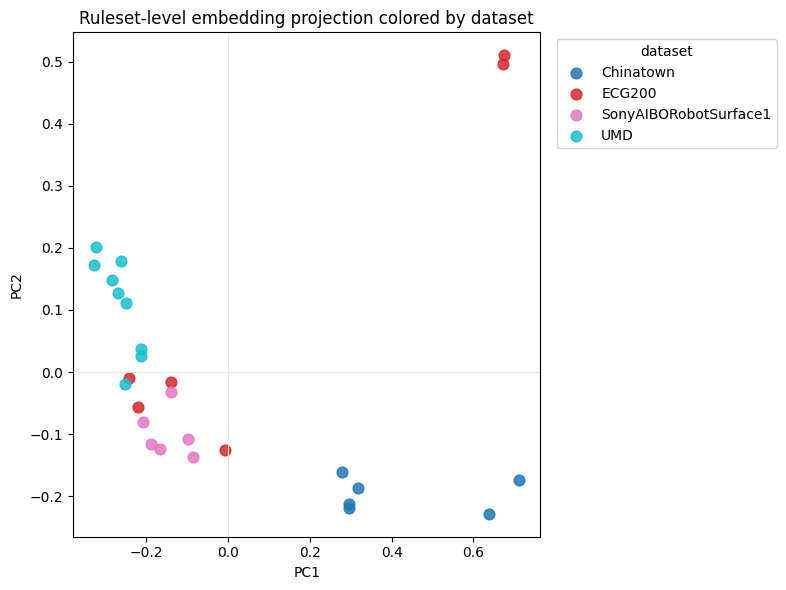

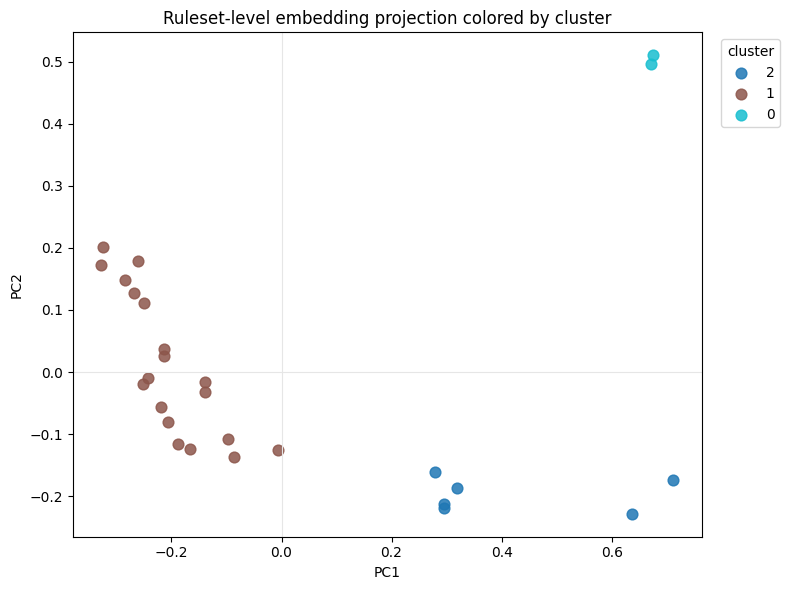

In [55]:
plot_scatter(ruleset_analysis, 'dataset', 'Ruleset-level embedding projection colored by dataset')
plot_scatter(ruleset_analysis, 'cluster', 'Ruleset-level embedding projection colored by cluster')


### Ruleset Projection With Accuracy Labels


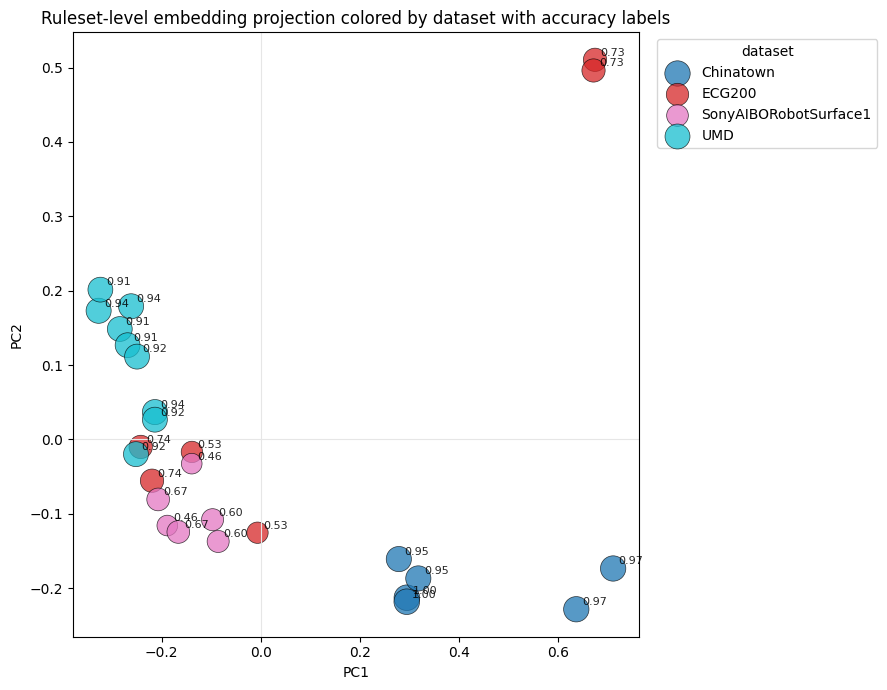

In [56]:
fig, ax = plt.subplots(figsize=(9, 7))
categories = list(pd.Series(ruleset_analysis['dataset']).astype(str).unique())
cmap = plt.cm.get_cmap('tab10', len(categories))

for idx, cat in enumerate(categories):
    sub = ruleset_analysis[ruleset_analysis['dataset'].astype(str) == cat]
    sizes = 120 + 220 * sub['accuracy'].to_numpy()
    ax.scatter(sub['pc1'], sub['pc2'], s=sizes, alpha=0.75, label=str(cat), color=cmap(idx), edgecolor='black', linewidth=0.5)
    for row in sub.itertuples(index=False):
        ax.annotate(
            f"{row.accuracy:.2f}",
            (row.pc1, row.pc2),
            xytext=(4, 3),
            textcoords='offset points',
            fontsize=8,
            alpha=0.85,
        )

ax.set_title('Ruleset-level embedding projection colored by dataset with accuracy labels')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='dataset', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.axhline(0, color='0.9', lw=0.8)
ax.axvline(0, color='0.9', lw=0.8)
plt.tight_layout()
plt.show()


### Interpreting PCA Dim


In [57]:
def pc_term_correlations(df, text_col='ruleset_text', pc_cols=('pc1', 'pc2'), ngram_range=(1, 2), top_k=12):
    vectorizer = TfidfVectorizer(ngram_range=ngram_range, lowercase=True, stop_words='english')
    X = vectorizer.fit_transform(df[text_col]).toarray()
    terms = np.array(vectorizer.get_feature_names_out())

    rows = []
    for pc in pc_cols:
        scores = df[pc].to_numpy()
        corrs = []
        for j, term in enumerate(terms):
            x = X[:, j]
            if np.std(x) == 0 or np.std(scores) == 0:
                corr = 0.0
            else:
                corr = float(np.corrcoef(x, scores)[0, 1])
            if np.isnan(corr):
                corr = 0.0
            corrs.append(corr)
        corrs = np.array(corrs)

        pos_idx = corrs.argsort()[::-1][:top_k]
        neg_idx = corrs.argsort()[:top_k]
        for rank, j in enumerate(pos_idx, start=1):
            rows.append({'pc': pc, 'direction': 'positive', 'rank': rank, 'term': terms[j], 'correlation': float(corrs[j])})
        for rank, j in enumerate(neg_idx, start=1):
            rows.append({'pc': pc, 'direction': 'negative', 'rank': rank, 'term': terms[j], 'correlation': float(corrs[j])})
    return pd.DataFrame(rows)

pc_term_df = pc_term_correlations(ruleset_analysis, text_col='ruleset_text', pc_cols=('pc1', 'pc2'), top_k=10)
pc_term_df


,pc,direction,rank,term,correlation
0,pc1,positive,1,value,0.860363
1,pc1,positive,2,average,0.708402
2,pc1,positive,3,time,0.635426
3,pc1,positive,4,series,0.618547
4,pc1,positive,5,zero,0.603843
5,pc1,positive,6,time series,0.602736
6,pc1,positive,7,roughly 08,0.591851
7,pc1,positive,8,08,0.591851
8,pc1,positive,9,average value,0.564027
9,pc1,positive,10,series average,0.564027


In [58]:
for pc in ['pc1', 'pc2']:
    print(f'\n=== {pc.upper()} ===')
    display(pc_term_df[pc_term_df['pc'] == pc].pivot(index='rank', columns='direction', values='term'))
    display(pc_term_df[pc_term_df['pc'] == pc].pivot(index='rank', columns='direction', values='correlation'))



=== PC1 ===


direction,negative,positive
rank,,
1,late,value
2,plateau,average
3,early late,time
4,high,series
5,narrow,zero
6,broad,time series
7,deep,roughly 08
8,middle region,08
9,valley,average value


direction,negative,positive
rank,,
1,-0.592806,0.860363
2,-0.591788,0.708402
3,-0.523963,0.635426
4,-0.473574,0.618547
5,-0.447582,0.603843
6,-0.447359,0.602736
7,-0.443486,0.591851
8,-0.394928,0.591851
9,-0.385495,0.564027



=== PC2 ===


direction,negative,positive
rank,,
1,region,value middle
2,early region,middle time
3,early,mean
4,average,mean value
5,zero,time series
6,roughly,middle
7,15,time
8,08,35
9,roughly 08,series 35


direction,negative,positive
rank,,
1,-0.770295,0.745396
2,-0.631023,0.745396
3,-0.604969,0.745396
4,-0.525539,0.745396
5,-0.438972,0.627988
6,-0.416639,0.614419
7,-0.374969,0.543033
8,-0.347136,0.524208
9,-0.347136,0.524208


In [59]:
pd.crosstab(ruleset_analysis['cluster'], ruleset_analysis['dataset'])


dataset,Chinatown,ECG200,SonyAIBORobotSurface1,UMD
cluster,,,,
0,0,2,0,0
1,0,4,6,9
2,6,0,0,0


In [60]:
ruleset_cluster_accuracy = (
    ruleset_analysis.groupby('cluster')
    .agg(count=('accuracy', 'size'), mean_accuracy=('accuracy', 'mean'))
    .sort_values('mean_accuracy', ascending=False)
)
ruleset_cluster_accuracy


,count,mean_accuracy
cluster,,
2,6,0.973333
1,19,0.753158
0,2,0.730000


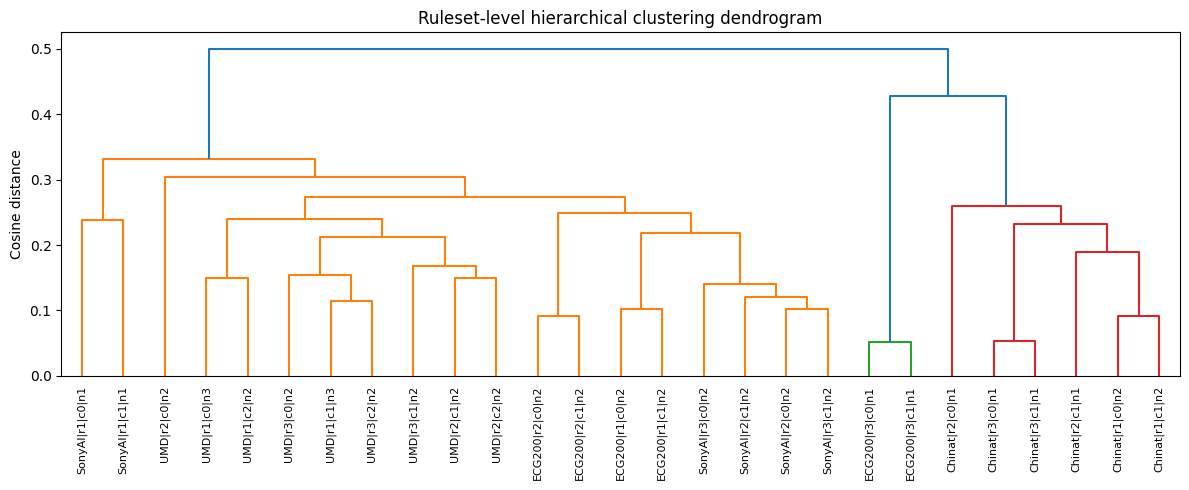

In [61]:
ruleset_labels = [
    f"{row.dataset[:6]}|r{row.run_idx}|c{row.class_label}|n{row.n_rules}"
    for row in ruleset_analysis.itertuples(index=False)
]
plot_dendrogram(ruleset_embeddings, ruleset_labels, 'Ruleset-level hierarchical clustering dendrogram', figsize=(12, 5))


In [62]:
show_cluster_examples(ruleset_analysis, text_col='ruleset_text', max_rows=8)



=== Cluster 0 | n=2 ===
Datasets: {'ECG200': 2}
Mean accuracy: 0.73


,dataset,run_idx,class_label,ruleset_text
10,ECG200,3,0,Mean value in the middle third of the time series is less than 0.35.
11,ECG200,3,1,Mean value in the middle third of the time series is at least 0.38.



=== Cluster 1 | n=19 ===
Datasets: {'UMD': 9, 'SonyAIBORobotSurface1': 6, 'ECG200': 4}
Mean accuracy: 0.7532


,dataset,run_idx,class_label,ruleset_text
6,ECG200,1,0,"After the early valley, the middle and late regions form a flat or gently rising plateau; the late segment does not show a sustained falling tail. When a tall late peak is present (around or above..."
7,ECG200,1,1,"After the early valley and mid-series plateau, the late region shows a falling tail, with values steadily decreasing toward the end. Alternatively, the early region stays relatively low (no clear ..."
8,ECG200,2,0,"After the early valley, the early middle region stays close to that minimum and well below the later plateau, forming a long, gradual upward slope (slow recovery). The late region sits at or above..."
9,ECG200,2,1,"After the early valley, the early middle region jumps quickly up to near the plateau level, forming a sharp upward step (fast recovery). From the middle into the late region the series tends to dr..."
12,SonyAIBORobotSurface1,1,0,"Two very deep troughs of almost equal depth appear, one in the early region and one in the late region, with the values between them oscillating around a mid‑level."
13,SonyAIBORobotSurface1,1,1,A single clearly deepest trough appears only in the late region after the main middle peak; all earlier dips stay noticeably higher than this late minimum.
14,SonyAIBORobotSurface1,2,0,"In the middle region the series is roughly flat or slightly falling, without a long smooth rising trend from the early low into a dominant mid-series peak. In the late region there are multiple sh..."
15,SonyAIBORobotSurface1,2,1,"After the early low trough the middle region shows a clear, extended rising trend that builds steadily into the main mid-series peak. In the late region there is a single pronounced trough followe..."



=== Cluster 2 | n=6 ===
Datasets: {'Chinatown': 6}
Mean accuracy: 0.9733


,dataset,run_idx,class_label,ruleset_text
0,Chinatown,1,0,"In the early region, average values are clearly above zero (around 0.1 or higher); the series starts at a moderate level before dipping. Within the early region, there is a strong downward drop (t..."
1,Chinatown,1,1,"In the early region, average values stay very close to zero (below about 0.1); the series begins on a low baseline. Within the early region, variation is small (the difference between highest and ..."
2,Chinatown,2,0,"In the early region (roughly the first quarter of time), values form a clearly elevated shoulder: at least one early point is around 0.2 or higher and the average level there is above roughly 0.08."
3,Chinatown,2,1,"In the early region (first quarter of time), the series hugs the baseline: all early points stay below about 0.15 and the average level there remains below roughly 0.07."
4,Chinatown,3,0,"In the early region (first third of the series), the average value is clearly above zero, roughly 0.08 or higher."
5,Chinatown,3,1,"In the early region (first third of the series), the average value stays near zero, below roughly 0.08."


# 3. Clustering

In [63]:
from pathlib import Path
from itertools import combinations

from scipy.cluster.hierarchy import leaves_list
from sklearn.metrics.pairwise import cosine_similarity


def top_terms_per_cluster(df, text_col='ruleset_text', ngram_range=(1, 2), top_k=12):
    vectorizer = TfidfVectorizer(ngram_range=ngram_range, lowercase=True, stop_words='english')
    X = vectorizer.fit_transform(df[text_col])
    terms = np.array(vectorizer.get_feature_names_out())

    rows = []
    for cluster_id in sorted(df['cluster'].unique()):
        mask = (df['cluster'].to_numpy() == cluster_id)
        mean_tfidf = np.asarray(X[mask].mean(axis=0)).ravel()
        top_idx = mean_tfidf.argsort()[::-1][:top_k]
        for rank, term_idx in enumerate(top_idx, start=1):
            rows.append({
                'cluster': cluster_id,
                'rank': rank,
                'term': terms[term_idx],
                'mean_tfidf': float(mean_tfidf[term_idx]),
            })
    return pd.DataFrame(rows)


def suggest_cluster_label(term_list):
    joined = ' | '.join(term_list).lower()
    if 'mean value' in joined or 'middle third' in joined:
        return 'middle-threshold'
    if 'early region' in joined and ('zero' in joined or 'baseline' in joined or 'average value' in joined):
        return 'early-baseline'
    if any(token in joined for token in ['plateau', 'valley', 'trough', 'peak', 'tail', 'rising', 'falling', 'recovery', 'spike']):
        return 'shape-trajectory'
    return 'mixed'


top_terms_df = top_terms_per_cluster(ruleset_analysis, text_col='ruleset_text', top_k=10)
cluster_label_rows = []
for cluster_id in sorted(top_terms_df['cluster'].unique()):
    term_list = top_terms_df[top_terms_df['cluster'] == cluster_id]['term'].tolist()
    cluster_label_rows.append({
        'cluster': cluster_id,
        'suggested_label': suggest_cluster_label(term_list),
        'top_terms': ', '.join(term_list[:8]),
    })
cluster_label_df = pd.DataFrame(cluster_label_rows)
cluster_label_map = dict(zip(cluster_label_df['cluster'], cluster_label_df['suggested_label']))

ruleset_analysis = ruleset_analysis.copy()
ruleset_analysis['cluster_label'] = ruleset_analysis['cluster'].map(cluster_label_map)

cluster_label_df


,cluster,suggested_label,top_terms
0,0,middle-threshold,"mean value, mean, middle time, value middle, time series, time, value, series 38"
1,1,shape-trajectory,"late, region, early, middle, plateau, peak, early late, trough"
2,2,early-baseline,"average, roughly, zero, early region, early, roughly 08, 08, region"


# 4. Cluster vs Performance

In [64]:
ruleset_analysis = ruleset_analysis.copy()
ruleset_analysis['dataset_accuracy_z'] = ruleset_analysis.groupby('dataset')['accuracy'].transform(
    lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) > 0 else 1.0)
)

perf_summary = (
    ruleset_analysis.groupby(['cluster', 'cluster_label'])
    .agg(
        count=('accuracy', 'size'),
        mean_accuracy=('accuracy', 'mean'),
        mean_dataset_z=('dataset_accuracy_z', 'mean'),
        datasets=('dataset', lambda s: ', '.join(sorted(pd.unique(s)))),
    )
    .sort_values('mean_accuracy', ascending=False)
    .reset_index()
)
perf_summary


,cluster,cluster_label,count,mean_accuracy,mean_dataset_z,datasets
0,2,early-baseline,6,0.973333,1.757853e-15,Chinatown
1,1,shape-trajectory,19,0.753158,-6.892455e-02,"ECG200, SonyAIBORobotSurface1, UMD"
2,0,middle-threshold,2,0.730000,6.547832e-01,ECG200


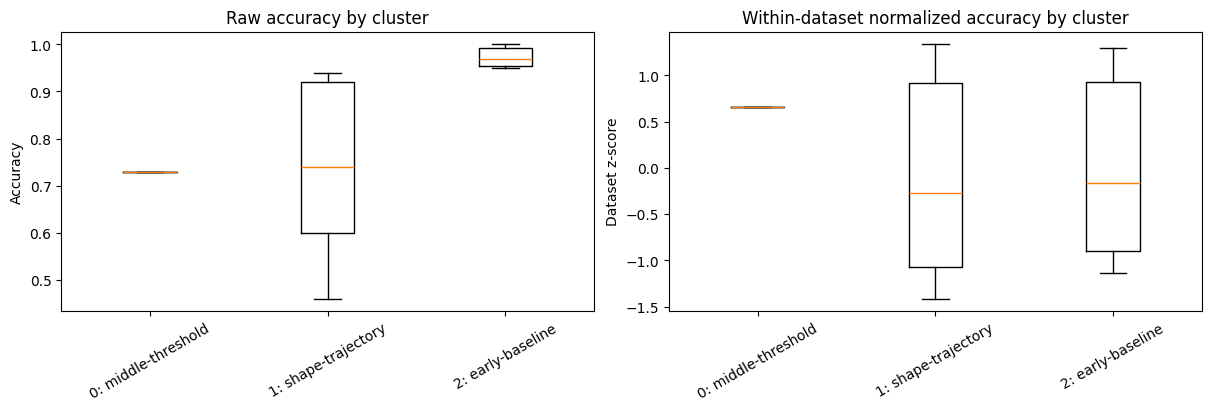

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

cluster_order = sorted(ruleset_analysis['cluster'].unique())
labels = [f"{c}: {cluster_label_map[c]}" for c in cluster_order]

raw_data = [ruleset_analysis.loc[ruleset_analysis['cluster'] == c, 'accuracy'].to_numpy() for c in cluster_order]
z_data = [ruleset_analysis.loc[ruleset_analysis['cluster'] == c, 'dataset_accuracy_z'].to_numpy() for c in cluster_order]

axes[0].boxplot(raw_data, tick_labels=labels)
axes[0].set_title('Raw accuracy by cluster')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=30)

axes[1].boxplot(z_data, tick_labels=labels)
axes[1].set_title('Within-dataset normalized accuracy by cluster')
axes[1].set_ylabel('Dataset z-score')
axes[1].tick_params(axis='x', rotation=30)

plt.show()


# 5. Nearest Neighbors and Cluster Medoids

In [66]:
ruleset_analysis = ruleset_analysis.reset_index(drop=True)
ruleset_analysis['ruleset_id'] = [f"{row.dataset}|run{row.run_idx}|class{row.class_label}" for row in ruleset_analysis.itertuples(index=False)]
ruleset_similarity = cosine_similarity(ruleset_embeddings)


def nearest_neighbor_table(df, sim_matrix, top_k=3):
    rows = []
    for i, row in df.iterrows():
        order = [j for j in np.argsort(sim_matrix[i])[::-1] if j != i][:top_k]
        for rank, j in enumerate(order, start=1):
            other = df.iloc[j]
            rows.append({
                'ruleset_id': row['ruleset_id'],
                'cluster': row['cluster'],
                'cluster_label': row['cluster_label'],
                'neighbor_rank': rank,
                'neighbor_id': other['ruleset_id'],
                'neighbor_cluster': other['cluster'],
                'neighbor_cluster_label': other['cluster_label'],
                'cosine_similarity': float(sim_matrix[i, j]),
            })
    return pd.DataFrame(rows)


def cluster_medoids(df, embeddings, sim_matrix):
    rows = []
    for cluster_id in sorted(df['cluster'].unique()):
        idx = np.where(df['cluster'].to_numpy() == cluster_id)[0]
        local_sim = sim_matrix[np.ix_(idx, idx)]
        mean_sim = local_sim.mean(axis=1)
        medoid_global_idx = idx[int(np.argmax(mean_sim))]
        medoid_row = df.iloc[medoid_global_idx]
        rows.append({
            'cluster': cluster_id,
            'cluster_label': medoid_row['cluster_label'],
            'ruleset_id': medoid_row['ruleset_id'],
            'dataset': medoid_row['dataset'],
            'run_idx': int(medoid_row['run_idx']),
            'class_label': int(medoid_row['class_label']),
            'mean_intra_cluster_similarity': float(np.max(mean_sim)),
            'ruleset_text': medoid_row['ruleset_text'],
        })
    return pd.DataFrame(rows)

nn_df = nearest_neighbor_table(ruleset_analysis, ruleset_similarity, top_k=3)
medoid_df = cluster_medoids(ruleset_analysis, ruleset_embeddings, ruleset_similarity)

medoid_df


,cluster,cluster_label,ruleset_id,dataset,run_idx,class_label,mean_intra_cluster_similarity,ruleset_text
0,0,middle-threshold,ECG200|run3|class0,ECG200,3,0,0.974273,Mean value in the middle third of the time series is less than 0.35.
1,1,shape-trajectory,SonyAIBORobotSurface1|run3|class1,SonyAIBORobotSurface1,3,1,0.795857,"In the early region, the series has a single main initial peak followed by a mostly continuous fall into one trough, without a second pronounced peak before that trough. From the early trough thro..."
2,2,early-baseline,Chinatown|run1|class0,Chinatown,1,0,0.849110,"In the early region, average values are clearly above zero (around 0.1 or higher); the series starts at a moderate level before dipping. Within the early region, there is a strong downward drop (t..."


In [67]:
nn_df.head(18)


,ruleset_id,cluster,cluster_label,neighbor_rank,neighbor_id,neighbor_cluster,neighbor_cluster_label,cosine_similarity
0,Chinatown|run1|class0,2,early-baseline,1,Chinatown|run1|class1,2,early-baseline,0.909001
1,Chinatown|run1|class0,2,early-baseline,2,Chinatown|run2|class0,2,early-baseline,0.841869
2,Chinatown|run1|class0,2,early-baseline,3,Chinatown|run3|class1,2,early-baseline,0.812157
3,Chinatown|run1|class1,2,early-baseline,1,Chinatown|run1|class0,2,early-baseline,0.909001
4,Chinatown|run1|class1,2,early-baseline,2,Chinatown|run3|class1,2,early-baseline,0.847112
5,Chinatown|run1|class1,2,early-baseline,3,Chinatown|run2|class1,2,early-baseline,0.838809
6,Chinatown|run2|class0,2,early-baseline,1,Chinatown|run1|class0,2,early-baseline,0.841869
7,Chinatown|run2|class0,2,early-baseline,2,ECG200|run1|class1,1,shape-trajectory,0.745007
8,Chinatown|run2|class0,2,early-baseline,3,Chinatown|run1|class1,2,early-baseline,0.731214
9,Chinatown|run2|class1,2,early-baseline,1,Chinatown|run1|class1,2,early-baseline,0.838809


# 6. Provisional Semantic Tags


In [68]:
def infer_feature_type(text):
    t = text.lower()
    if 'mean value' in t or 'average value' in t:
        return 'region-statistic'
    if any(tok in t for tok in ['at least', 'below', 'above', 'around', 'less than', 'greater than']):
        return 'threshold'
    if any(tok in t for tok in ['plateau', 'valley', 'trough', 'peak', 'tail', 'recovery', 'rising', 'falling', 'spike']):
        return 'shape-trajectory'
    return 'mixed'


def infer_time_focus(text):
    t = text.lower()
    hits = [region for region in ['early', 'middle', 'late'] if region in t]
    if len(hits) == 0:
        return 'unspecified'
    if len(hits) == 1:
        return hits[0]
    return 'multi-region'


def infer_shape_terms(text):
    t = text.lower()
    vocab = ['plateau', 'valley', 'trough', 'peak', 'tail', 'recovery', 'rise', 'rising', 'fall', 'falling', 'baseline', 'spike', 'dip', 'block']
    found = [term for term in vocab if term in t]
    return ', '.join(found) if found else 'none'

provisional_tags = ruleset_analysis[['ruleset_id', 'dataset', 'run_idx', 'class_label', 'cluster', 'cluster_label', 'ruleset_text']].copy()
provisional_tags['feature_type_seed'] = provisional_tags['ruleset_text'].map(infer_feature_type)
provisional_tags['time_focus_seed'] = provisional_tags['ruleset_text'].map(infer_time_focus)
provisional_tags['shape_terms_seed'] = provisional_tags['ruleset_text'].map(infer_shape_terms)
provisional_tags['manual_feature_type'] = ''
provisional_tags['manual_time_focus'] = ''
provisional_tags['manual_shape_terms'] = ''
provisional_tags['manual_notes'] = ''

out_csv = REPO_ROOT / 'results' / 'llm_explore' / 'promptV3_ruleset_provisional_semantic_tags.csv'
provisional_tags.to_csv(out_csv, index=False)
print(f'Wrote {out_csv}')
provisional_tags.head(10)


Wrote /home/felix/TSC_LLM_rules/results/llm_explore/promptV3_ruleset_provisional_semantic_tags.csv


,ruleset_id,dataset,run_idx,class_label,cluster,cluster_label,ruleset_text,feature_type_seed,time_focus_seed,shape_terms_seed,manual_feature_type,manual_time_focus,manual_shape_terms,manual_notes
0,Chinatown|run1|class0,Chinatown,1,0,2,early-baseline,"In the early region, average values are clearly above zero (around 0.1 or higher); the series starts at a moderate level before dipping. Within the early region, there is a strong downward drop (t...",region-statistic,early,dip,,,,
1,Chinatown|run1|class1,Chinatown,1,1,2,early-baseline,"In the early region, average values stay very close to zero (below about 0.1); the series begins on a low baseline. Within the early region, variation is small (the difference between highest and ...",region-statistic,early,baseline,,,,
2,Chinatown|run2|class0,Chinatown,2,0,2,early-baseline,"In the early region (roughly the first quarter of time), values form a clearly elevated shoulder: at least one early point is around 0.2 or higher and the average level there is above roughly 0.08.",threshold,early,none,,,,
3,Chinatown|run2|class1,Chinatown,2,1,2,early-baseline,"In the early region (first quarter of time), the series hugs the baseline: all early points stay below about 0.15 and the average level there remains below roughly 0.07.",threshold,early,baseline,,,,
4,Chinatown|run3|class0,Chinatown,3,0,2,early-baseline,"In the early region (first third of the series), the average value is clearly above zero, roughly 0.08 or higher.",region-statistic,early,none,,,,
5,Chinatown|run3|class1,Chinatown,3,1,2,early-baseline,"In the early region (first third of the series), the average value stays near zero, below roughly 0.08.",region-statistic,early,none,,,,
6,ECG200|run1|class0,ECG200,1,0,1,shape-trajectory,"After the early valley, the middle and late regions form a flat or gently rising plateau; the late segment does not show a sustained falling tail. When a tall late peak is present (around or above...",threshold,multi-region,"plateau, valley, peak, tail, rising, fall, falling",,,,
7,ECG200|run1|class1,ECG200,1,1,1,shape-trajectory,"After the early valley and mid-series plateau, the late region shows a falling tail, with values steadily decreasing toward the end. Alternatively, the early region stays relatively low (no clear ...",threshold,multi-region,"plateau, valley, peak, tail, fall, falling, spike",,,,
8,ECG200|run2|class0,ECG200,2,0,1,shape-trajectory,"After the early valley, the early middle region stays close to that minimum and well below the later plateau, forming a long, gradual upward slope (slow recovery). The late region sits at or above...",threshold,multi-region,"plateau, valley, recovery",,,,
9,ECG200|run2|class1,ECG200,2,1,1,shape-trajectory,"After the early valley, the early middle region jumps quickly up to near the plateau level, forming a sharp upward step (fast recovery). From the middle into the late region the series tends to dr...",shape-trajectory,multi-region,"plateau, valley, peak, recovery",,,,


In [69]:
pd.crosstab(provisional_tags['cluster_label'], provisional_tags['feature_type_seed'])


feature_type_seed,region-statistic,shape-trajectory,threshold
cluster_label,,,
early-baseline,4,0,2
middle-threshold,2,0,0
shape-trajectory,0,9,10


In [70]:
pd.crosstab(provisional_tags['cluster_label'], provisional_tags['time_focus_seed'])


time_focus_seed,early,middle,multi-region
cluster_label,,,
early-baseline,6,0,0
middle-threshold,0,2,0
shape-trajectory,0,0,19


# 7. Per-Class Stability Across Runs

In [71]:
stability_rows = []
for (dataset, class_label), sub in ruleset_analysis.groupby(['dataset', 'class_label']):
    idx = sub.index.to_list()
    pair_sims = []
    pair_labels = []
    for i, j in combinations(idx, 2):
        pair_sims.append(float(ruleset_similarity[i, j]))
        pair_labels.append((ruleset_analysis.loc[i, 'run_idx'], ruleset_analysis.loc[j, 'run_idx']))

    stability_rows.append({
        'dataset': dataset,
        'class_label': class_label,
        'n_runs': len(sub),
        'mean_pairwise_similarity': float(np.mean(pair_sims)),
        'min_pairwise_similarity': float(np.min(pair_sims)),
        'max_pairwise_similarity': float(np.max(pair_sims)),
        'pairwise_similarities': pair_sims,
        'run_pairs': pair_labels,
    })

stability_df = pd.DataFrame(stability_rows).sort_values(['dataset', 'class_label']).reset_index(drop=True)
stability_df


,dataset,class_label,n_runs,mean_pairwise_similarity,min_pairwise_similarity,max_pairwise_similarity,pairwise_similarities,run_pairs
0,Chinatown,0,3,0.757883,0.681514,0.841869,"[0.8418686389923096, 0.7502678632736206, 0.6815136671066284]","[(1, 2), (1, 3), (2, 3)]"
1,Chinatown,1,3,0.817422,0.766343,0.847112,"[0.8388092517852783, 0.8471124172210693, 0.7663432955741882]","[(1, 2), (1, 3), (2, 3)]"
2,ECG200,0,3,0.492573,0.271905,0.800589,"[0.8005894422531128, 0.4052239954471588, 0.27190542221069336]","[(1, 2), (1, 3), (2, 3)]"
3,ECG200,1,3,0.522753,0.338316,0.768964,"[0.7689637541770935, 0.4609801769256592, 0.3383162021636963]","[(1, 2), (1, 3), (2, 3)]"
4,SonyAIBORobotSurface1,0,3,0.761728,0.699817,0.869687,"[0.6998170614242554, 0.7156810760498047, 0.8696873188018799]","[(1, 2), (1, 3), (2, 3)]"
5,SonyAIBORobotSurface1,1,3,0.793401,0.739012,0.881687,"[0.7595041990280151, 0.7390121221542358, 0.8816865682601929]","[(1, 2), (1, 3), (2, 3)]"
6,UMD,0,3,0.667378,0.621525,0.692619,"[0.6879910826683044, 0.6926192045211792, 0.6215248107910156]","[(1, 2), (1, 3), (2, 3)]"
7,UMD,1,3,0.824232,0.785819,0.854525,"[0.7858192324638367, 0.854525089263916, 0.8323519229888916]","[(1, 2), (1, 3), (2, 3)]"
8,UMD,2,3,0.789798,0.754422,0.807848,"[0.8071246147155762, 0.7544220685958862, 0.8078483939170837]","[(1, 2), (1, 3), (2, 3)]"


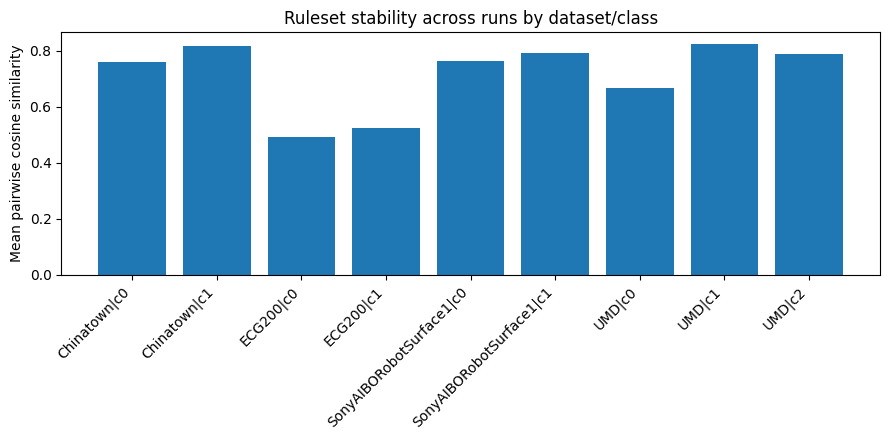

In [72]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = [f"{row.dataset}|c{row.class_label}" for row in stability_df.itertuples(index=False)]
values = stability_df['mean_pairwise_similarity'].to_numpy()
ax.bar(range(len(values)), values)
ax.set_xticks(range(len(values)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Mean pairwise cosine similarity')
ax.set_title('Ruleset stability across runs by dataset/class')
plt.tight_layout()
plt.show()
